In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from pathlib import Path
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

print(f"TensorFlow version: {tf.__version__}")
print(f"GPUs available: {tf.config.list_physical_devices('GPU')}")
print(f"CPUs available: {tf.config.list_physical_devices('CPU')}")

I0000 00:00:1779826647.055289  118475 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779826647.114641  118475 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779826648.470981  118475 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
CPUs available: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [2]:
from pathlib import Path
import category_encoders as ce
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler

data_path = Path("/mnt/e/Users/KilianAT/Documents/Estudios/Weiterbildung/Data Science/Proyecto/mle_liora_london_firefighter/data")

# Load pre-encoding dataset
df = pd.read_csv(data_path / "dataset_pre_encoding.csv")

# Same split as modeling notebook
TARGET    = "AttendanceTimeSeconds"
DROP_COLS = ["index", "IncidentNumber", "avg_speed", "PumpOrder"]

train_df = df[df["CalYear"] <= 2023].copy()
test_df  = df[df["CalYear"] == 2024].copy()
val_df   = df[df["CalYear"] >= 2025].copy()

def get_data(data):
    to_drop = [TARGET] + DROP_COLS
    X = data.drop(columns=[c for c in to_drop if c in data.columns])
    y = data[TARGET].values
    return X, y

X_train, y_train = get_data(train_df)
X_test,  y_test  = get_data(test_df)
X_val,   y_val   = get_data(val_df)

print(f"Train: {X_train.shape} | Test: {X_test.shape} | Val: {X_val.shape}")

Train: (310660, 21) | Test: (116221, 21) | Val: (137825, 21)


In [3]:
# Same EncodingTransformer as modeling notebook
feature_config = {
    "Month":             {"encoding": "CYCLIC"},
    "Weekday":           {"encoding": "CYCLIC"},
    "Hour":              {"encoding": "CYCLIC"},
    "CalYear":           {"encoding": "NUMERIC_KEEP"},
    "Is_Nightshift":     {"encoding": "BINARY_KEEP"},
    "Is_Rush_Hour":      {"encoding": "BINARY_KEEP"},
    "Is_Weekend":        {"encoding": "BINARY_KEEP"},
    "Is_Public_Holiday": {"encoding": "BINARY_KEEP"},
    "Is_SpecialService": {"encoding": "BINARY_KEEP"},
    "Is_RepeatedCall":   {"encoding": "BINARY_KEEP"},
    "Is_central_London": {"encoding": "BINARY_KEEP"},
    "Latitude":          {"encoding": "NUMERIC_KEEP"},
    "Longitude":         {"encoding": "NUMERIC_KEEP"},
    "distance_fire_to_station": {"encoding": "NUMERIC_KEEP"},
    "IncidentGroup":     {"encoding": "ONE_HOT"},
    "PropertyCategory":  {"encoding": "ONE_HOT"},
    "NumOfCalls_bucket": {"encoding": "ONE_HOT"},
    "SpecialServiceType":{"encoding": "TOP_N_PLUS_ONE_HOT", "top_n": 10},
    "DeployedFromStation_Name": {"encoding": "LEAVE_ONE_OUT_TARGET"},
    "PropertyType":      {"encoding": "LEAVE_ONE_OUT_TARGET"},
    "IncGeo_BoroughName":{"encoding": "LEAVE_ONE_OUT_TARGET"}
}

class EncodingTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, config=None):
        self.config = config or feature_config
        self.fitted_encoders_ = {}

    def fit(self, X, y=None):
        self.fitted_encoders_ = {}
        X = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        for col, cfg in self.config.items():
            if col not in X.columns:
                continue
            method = cfg["encoding"]
            if method in ["ONE_HOT", "TOP_N_PLUS_ONE_HOT"]:
                data_to_fit = X[[col]].copy()
                top_n_list = None
                if method == "TOP_N_PLUS_ONE_HOT":
                    top_n_list = X[col].value_counts().head(cfg.get("top_n", 10)).index.tolist()
                    data_to_fit[col] = data_to_fit[col].where(data_to_fit[col].isin(top_n_list), "Other")
                enc = ce.OneHotEncoder(cols=[col], use_cat_names=True).fit(data_to_fit)
                self.fitted_encoders_[col] = (enc, top_n_list)
            elif method == "LEAVE_ONE_OUT_TARGET":
                enc = ce.LeaveOneOutEncoder(cols=[col]).fit(X[[col]], y)
                self.fitted_encoders_[col] = enc
        return self

    def transform(self, X, y=None):
        X = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        encoded_parts = []
        for col, cfg in self.config.items():
            if col not in X.columns:
                continue
            method = cfg["encoding"]
            if method in ["NUMERIC_KEEP", "BINARY_KEEP"]:
                encoded_parts.append(X[[col]])
            elif method == "CYCLIC":
                periods = {"Month": 12, "Weekday": 7, "Hour": 24}
                p = periods[col]
                encoded_parts.append(pd.DataFrame({
                    f"{col}_sin": np.sin(2 * np.pi * X[col] / p),
                    f"{col}_cos": np.cos(2 * np.pi * X[col] / p)
                }, index=X.index))
            elif method in ["ONE_HOT", "TOP_N_PLUS_ONE_HOT"]:
                enc, top_n_list = self.fitted_encoders_[col]
                data_to_transform = X[[col]].copy()
                if top_n_list:
                    data_to_transform[col] = data_to_transform[col].where(
                        data_to_transform[col].isin(top_n_list), "Other"
                    )
                encoded_parts.append(enc.transform(data_to_transform))
            elif method == "LEAVE_ONE_OUT_TARGET":
                encoded_parts.append(self.fitted_encoders_[col].transform(X[[col]]))
        return pd.concat(encoded_parts, axis=1).reset_index(drop=True).values

# Fit encoder on train only, transform all three sets
encoder = EncodingTransformer()
encoder.fit(X_train, y_train)

X_train_enc = encoder.transform(X_train)
X_test_enc  = encoder.transform(X_test)
X_val_enc   = encoder.transform(X_val)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled  = scaler.transform(X_test_enc)
X_val_scaled   = scaler.transform(X_val_enc)

print(f"Features after encoding: {X_train_scaled.shape[1]}")
print("Encoding and scaling done!")

Features after encoding: 49
Encoding and scaling done!


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Number of input features
n_features = X_train_scaled.shape[1]
print(f"Input features: {n_features}")

# Build model
model = Sequential([
    # Input layer
    Dense(256, activation='relu', input_shape=(n_features,)),
    BatchNormalization(),
    Dropout(0.3),

    # Hidden layer 1
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    # Hidden layer 2
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    # Hidden layer 3
    Dense(32, activation='relu'),

    # Output layer — single neuron, no activation (regression)
    Dense(1)
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()

Input features: 49


/home/kilian/venvs/mle_liora_london_firefighter/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1779826652.217776  118475 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5561 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        12,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,857 (226.00 KB)

 Trainable params: 56,961 (222.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [5]:
# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,          # stop if no improvement for 10 epochs
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,           # halve learning rate when stuck
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# Train
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=100,
    batch_size=512,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/100


I0000 00:00:1779826654.598137  118666 service.cc:153] XLA service 0x7f8e6004bc80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779826654.598164  118666 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3070, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1779826654.635746  118666 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779826654.833562  118666 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1779826654.894427  118666 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3446__.32
I0000 00:00:1779826655.120273  118666 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I00

 92/607 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 107570.2919 - mae: 309.8218

I0000 00:00:1779826658.678435  118666 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


597/607 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 74113.1112 - mae: 239.2116

I0000 00:00:1779826659.879305  118663 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3446__.32
I0000 00:00:1779826660.191822  118663 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1779826660.548552  118663 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1779826660.861727  118663 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1779826661.167476

607/607 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 73553.5259 - mae: 237.8146

I0000 00:00:1779826664.769954  118666 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


607/607 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 39907.8984 - mae: 153.7393 - val_loss: 5747.5493 - val_mae: 56.0180 - learning_rate: 0.0010
Epoch 2/100
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6360.5562 - mae: 58.9432 - val_loss: 5612.5869 - val_mae: 54.3655 - learning_rate: 0.0010
Epoch 3/100
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6277.3037 - mae: 58.5855 - val_loss: 5579.0737 - val_mae: 54.1494 - learning_rate: 0.0010
Epoch 4/100
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6181.6709 - mae: 58.0044 - val_loss: 5567.1631 - val_mae: 53.8637 - learning_rate: 0.0010
Epoch 5/100
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6147.9873 - mae: 57.7468 - val_loss: 5565.5366 - val_mae: 53.6214 - learning_rate: 0.0010
Epoch 6/100
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6074.1826 - mae: 57.3964 - val_loss: 5550.6401 - val_mae: 53.6028 - learning_rate: 0.0010
Epoch 7/100
607/607 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6036.4302 - mae: 57.1688 - val_loss: 5546

I0000 00:00:1779826747.553781  118665 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


3606/3632 ━━━━━━━━━━━━━━━━━━━━ 0s 797us/step

I0000 00:00:1779826751.411914  118663 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


3632/3632 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
Deep Learning results on test set:
  R²:   0.5483
  MAE:  53.1954
  RMSE: 73.4904


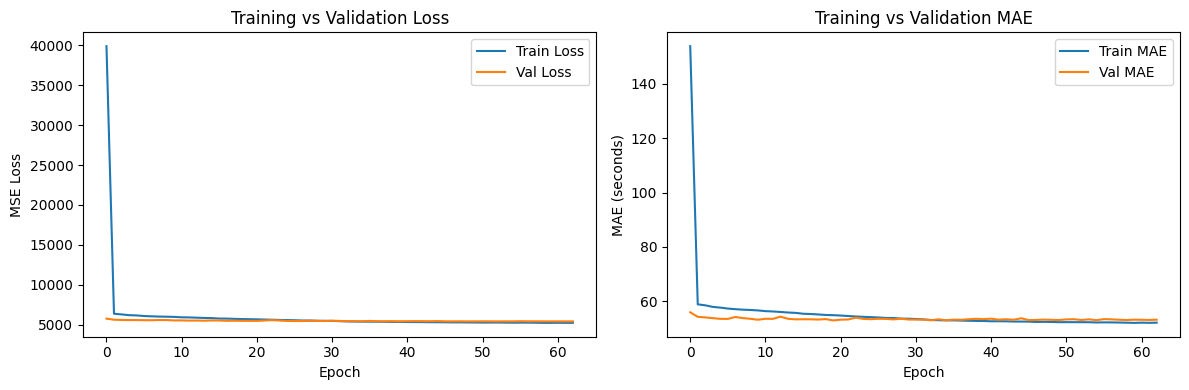

In [6]:
# Evaluate on test set
y_pred = model.predict(X_test_scaled).flatten()

print("Deep Learning results on test set:")
print(f"  R²:   {r2_score(y_test, y_pred):.4f}")
print(f"  MAE:  {mean_absolute_error(y_test, y_pred):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

# Training curve
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'],     label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE (seconds)')
plt.title('Training vs Validation MAE')
plt.legend()

plt.tight_layout()
plt.show()

In [7]:
#~just verified that I´m using the GPU and not the CDU
import tensorflow as tf
print("GPUs:", tf.config.list_physical_devices('GPU'))

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

n_features = X_train_scaled.shape[1]

# Improved architecture — wider and deeper
model_v2 = Sequential([
    # Input block — wider
    Dense(512, activation='relu', input_shape=(n_features,)),
    BatchNormalization(),
    Dropout(0.3),

    # Block 2
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    # Block 3
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    # Block 4
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    # Block 5 — added vs v1
    Dense(32, activation='relu'),
    BatchNormalization(),

    # Output
    Dense(1)
])

model_v2.compile(
    optimizer=Adam(learning_rate=0.0005),  # lower learning rate for better convergence
    loss='mse',
    metrics=['mae']
)

model_v2.summary()

/home/kilian/venvs/mle_liora_london_firefighter/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 512)            │        25,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 204,161 (797.50 KB)

 Trainable params: 202,177 (789.75 KB)

 Non-trainable params: 1,984 (7.75 KB)

In [9]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,               # more patience than v1 (10→15)
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,                # more patience (5→7)
    min_lr=1e-7,
    verbose=1
)

history_v2 = model_v2.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=200,                # more epochs (100→200)
    batch_size=256,            # smaller batch for better gradients (512→256)
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/200


I0000 00:00:1779826885.474980  118663 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_247713__.46
I0000 00:00:1779826885.629792  118663 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1779826886.225715  118663 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1779826886.486468  126652 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_38', 36 bytes spill stores, 36 bytes spill loads

I0000 00:00:1779826886.501511  118663 dot_search_space.cc:240] All configs were filtered out because non

1199/1214 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 105881.1947 - mae: 310.1869

I0000 00:00:1779826893.278337  118664 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_247713__.46
I0000 00:00:1779826893.345425  118664 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1779826893.615376  118664 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1779826893.986203  118664 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1779826894.5207

1214/1214 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 105820.1563 - mae: 310.1142

I0000 00:00:1779826901.507907  118666 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


1214/1214 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 100880.3203 - mae: 304.2205 - val_loss: 89282.5156 - val_mae: 288.5963 - learning_rate: 5.0000e-04
Epoch 2/200
1214/1214 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 72498.5625 - mae: 258.1987 - val_loss: 54865.5078 - val_mae: 222.0651 - learning_rate: 5.0000e-04
Epoch 3/200
1214/1214 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 39899.7930 - mae: 184.7499 - val_loss: 24954.6309 - val_mae: 141.2628 - learning_rate: 5.0000e-04
Epoch 4/200
1214/1214 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 16056.9717 - mae: 105.6138 - val_loss: 8708.0117 - val_mae: 69.8761 - learning_rate: 5.0000e-04
Epoch 5/200
1214/1214 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 6699.1162 - mae: 58.7806 - val_loss: 5647.5527 - val_mae: 53.3371 - learning_rate: 5.0000e-04
Epoch 6/200
1214/1214 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 5328.1450 - mae: 52.4228 - val_loss: 5515.2397 - val_mae: 54.0606 - learning_rate: 5.0000e-04
Epoch 7/200
1214/1214 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step

In [10]:
y_pred_v2 = model_v2.predict(X_test_scaled).flatten()

print("Deep Learning v2 results:")
print(f"  R²:   {r2_score(y_test, y_pred_v2):.4f}")
print(f"  MAE:  {mean_absolute_error(y_test, y_pred_v2):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_v2)):.4f}")

print("\nComparison:")
print(f"  DL v1:    R²=0.5486 | MAE=53.23 | RMSE=73.46")
print(f"  XGBoost:  R²=0.5845 | MAE=50.31 | RMSE=70.66")

3632/3632 ━━━━━━━━━━━━━━━━━━━━ 4s 975us/step
Deep Learning v2 results:
  R²:   0.5481
  MAE:  53.3747
  RMSE: 73.5001

Comparison:
  DL v1:    R²=0.5486 | MAE=53.23 | RMSE=73.46
  XGBoost:  R²=0.5845 | MAE=50.31 | RMSE=70.66


In [ ]:
#Lets evaluate 